# Jack's Car Rental Case Study

This notebook implements the **Jack's Car Rental** problem from Example 4.2 of Sutton & Barto's *Reinforcement Learning: An Introduction*.

## 1. Problem Formulation

### State Space ($\mathcal{S}$)
The state is a pair $(n_1, n_2)$ representing the number of cars at each of the two locations at the end of the day. 
- $0 \leq n_1, n_2 \leq 20$
- Total states: $21 \times 21 = 441$

### Action Space ($\mathcal{A}$)
The number of cars Jack moves from Location 1 to Location 2 overnight.
- $a \in \{-5, -4, \ldots, 0, \ldots, 4, 5\}$
- Positive $a$: Moving cars from Loc 1 $\to$ Loc 2.
- Negative $a$: Moving cars from Loc 2 $\to$ Loc 1.

### Rewards ($\mathcal{R}$)
- $+10$ for each car rented (only if a car is available).
- $-2$ for each car moved overnight.

### Dynamics ($p$)
Rentals and returns follow a Poisson distribution: $P(n) = \frac{\lambda^n}{n!} e^{-\lambda}$.
- **Location 1**: $\lambda_{\text{rent}} = 3, \lambda_{\text{return}} = 3$
- **Location 2**: $\lambda_{\text{rent}} = 4, \lambda_{\text{return}} = 2$

In [3]:
%pip install scipy

  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
import seaborn as sns

class JacksCarRentalEnv:
    def __init__(self):
        self.max_cars = 20
        self.max_move = 5
        self.gamma = 0.9
        self.rental_reward = 10
        self.move_cost = 2
        
        # Poisson parameters
        self.rent_loc1 = 3
        self.return_loc1 = 3
        self.rent_loc2 = 4
        self.return_loc2 = 2
        
        # Range of Poisson values to consider (up to 11 is usually enough for these lambdas)
        self.poisson_range = 11
        
        # Precompute Poisson PMFs
        self.p_rent1 = [poisson.pmf(i, self.rent_loc1) for i in range(self.poisson_range)]
        self.p_ret1 = [poisson.pmf(i, self.return_loc1) for i in range(self.poisson_range)]
        self.p_rent2 = [poisson.pmf(i, self.rent_loc2) for i in range(self.poisson_range)]
        self.p_ret2 = [poisson.pmf(i, self.return_loc2) for i in range(self.poisson_range)]
        
    def get_expected_return(self, state, action, V):
        """
        Computes the expected return for a given state and action.
        Sum over all possible rentals and returns.
        """
        expected_val = 0.0
        
        # Cost of moving cars
        expected_val -= self.move_cost * abs(action)
        
        # Cars available at each location after overnight move
        # Note: action is Loc 1 -> Loc 2
        cars_loc1 = int(min(state[0] - action, self.max_cars))
        cars_loc2 = int(min(state[1] + action, self.max_cars))
        
        # Iterate over all possible rental outcomes
        for r1 in range(self.poisson_range):
            for r2 in range(self.poisson_range):
                # Prob of this rental outcome
                p_rental = self.p_rent1[r1] * self.p_rent2[r2]
                
                # Actual rentals (cannot rent more than we have)
                rent1 = min(cars_loc1, r1)
                rent2 = min(cars_loc2, r2)
                reward = (rent1 + rent2) * self.rental_reward
                
                # Iterate over all possible return outcomes
                for ret1 in range(self.poisson_range):
                    for ret2 in range(self.poisson_range):
                        # Prob of this return outcome
                        p_return = self.p_ret1[ret1] * self.p_ret2[ret2]
                        
                        prob = p_rental * p_return
                        
                        # New state (clamped to max_cars)
                        s1 = min(cars_loc1 - rent1 + ret1, self.max_cars)
                        s2 = min(cars_loc2 - rent2 + ret2, self.max_cars)
                        
                        # Bellman update term
                        expected_val += prob * (reward + self.gamma * V[s1, s2])
                        
        return expected_val

## 2. Policy Iteration

We use **Policy Iteration** because it typically converges faster in discrete MDPs with complex dynamics like this one.

In [5]:
def policy_evaluation(env, V, policy, theta=0.1):
    """Standard iterative policy evaluation."""
    while True:
        delta = 0
        for i in range(env.max_cars + 1):
            for j in range(env.max_cars + 1):
                old_v = V[i, j]
                action = policy[i, j]
                V[i, j] = env.get_expected_return((i, j), action, V)
                delta = max(delta, abs(old_v - V[i, j]))
        print(f"  Eval Delta: {delta:.2f}")
        if delta < theta:
            break
    return V

def policy_improvement(env, V, policy):
    """Greedy policy improvement."""
    policy_stable = True
    actions = np.arange(-env.max_move, env.max_move + 1)
    
    for i in range(env.max_cars + 1):
        for j in range(env.max_cars + 1):
            old_action = policy[i, j]
            
            # Compute Q(s, a) for all actions
            action_values = []
            for act in actions:
                # Constraint: cannot move more cars than available at Loc 1
                # And cannot move more from Loc 2 than available there (if act is negative)
                if (act >= 0 and i >= act) or (act < 0 and j >= abs(act)):
                    action_values.append(env.get_expected_return((i, j), act, V))
                else:
                    action_values.append(-np.inf)
            
            best_action = actions[np.argmax(action_values)]
            policy[i, j] = best_action
            
            if old_action != best_action:
                policy_stable = False
    return policy, policy_stable

Iteration 0:
  Eval Delta: 191.14
  Eval Delta: 131.92
  Eval Delta: 88.62
  Eval Delta: 66.28
  Eval Delta: 52.30
  Eval Delta: 40.50
  Eval Delta: 31.57
  Eval Delta: 25.01
  Eval Delta: 20.78
  Eval Delta: 17.37
  Eval Delta: 14.49
  Eval Delta: 12.05
  Eval Delta: 10.01
  Eval Delta: 8.29
  Eval Delta: 6.85
  Eval Delta: 5.65
  Eval Delta: 4.66
  Eval Delta: 3.83
  Eval Delta: 3.15
  Eval Delta: 2.59
  Eval Delta: 2.12
  Eval Delta: 1.74
  Eval Delta: 1.43
  Eval Delta: 1.17
  Eval Delta: 0.96
  Eval Delta: 0.78
  Eval Delta: 0.64
  Eval Delta: 0.52
  Eval Delta: 0.43
  Eval Delta: 0.35
  Eval Delta: 0.28
  Eval Delta: 0.23
  Eval Delta: 0.19
  Eval Delta: 0.15
  Eval Delta: 0.13
  Eval Delta: 0.10
  Eval Delta: 0.08
Iteration 1:
  Eval Delta: 64.05
  Eval Delta: 4.47
  Eval Delta: 2.03
  Eval Delta: 1.56
  Eval Delta: 1.34
  Eval Delta: 1.11
  Eval Delta: 0.91
  Eval Delta: 0.74
  Eval Delta: 0.60
  Eval Delta: 0.49
  Eval Delta: 0.40
  Eval Delta: 0.32
  Eval Delta: 0.26
  Eval D

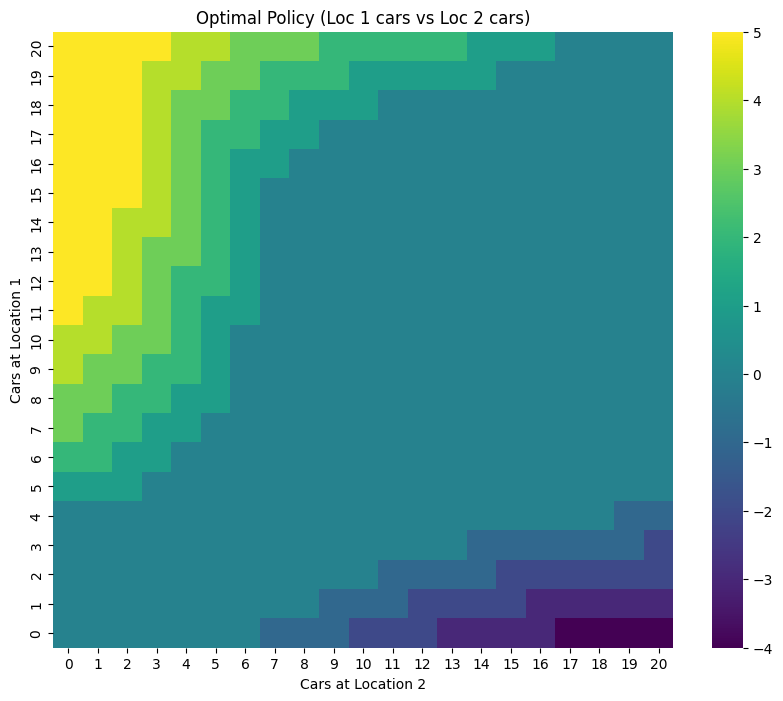

In [6]:
env = JacksCarRentalEnv()
V = np.zeros((env.max_cars + 1, env.max_cars + 1))
policy = np.zeros((env.max_cars + 1, env.max_cars + 1), dtype=int)

iterations = 0
while True:
    print(f"Iteration {iterations}:")
    # 1. Evaluate
    V = policy_evaluation(env, V, policy)
    # 2. Improve
    policy, stable = policy_improvement(env, V, policy)
    
    iterations += 1
    if stable:
        print("Converged!")
        break
        
# Visualize optimal policy
plt.figure(figsize=(10, 8))
sns.heatmap(policy, annot=False, cmap="viridis")
plt.title("Optimal Policy (Loc 1 cars vs Loc 2 cars)")
plt.xlabel("Cars at Location 2")
plt.ylabel("Cars at Location 1")
plt.gca().invert_yaxis()
plt.show()